# 📊 BubbleSeg — Experiment Analysis Notebook
This notebook loads evaluation results from the synthetic or real datasets,  
visualizes experiment metrics, and generates thesis-ready tables and figures.

In [10]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from plotting_module import (
    load_experiment,
    run_all_plots_for_experiment,
    generate_experiment_comparison,
)

In [11]:
# Example: use your own experiment output folder
#exp_dir = "results/maskrcnn_resnet50_fpn_transfer_real_20251218_1643"
exp_dir = "results/real_test/maskrcnn_resnet50_fpn_synth_20260106_0917"

In [12]:
data = load_experiment(exp_dir)
summary = data["json"]
df = data["df"]

display(df.head())
print("Loaded:", data["name"])
print("Rows (images):", len(df))

# %%
# === 2) Quick summary table (thesis-friendly) ===
sem = summary.get("semantic_metrics", {})
inst = summary.get("instance_metrics", {})
tim = summary.get("timing", {})

rows = [
    ("Dice", sem.get("dice", np.nan)),
    ("IoU", sem.get("iou", np.nan)),
    ("Precision", sem.get("precision", np.nan)),
    ("Recall", sem.get("recall", np.nan)),
    ("F1", sem.get("f1", np.nan)),
    ("Pred avg bubbles", inst.get("avg_bubbles", np.nan)),
    ("Pred mean area", inst.get("mean_area", np.nan)),
    ("GT avg bubbles", inst.get("gt_avg_bubbles", np.nan)),
    ("GT mean area", inst.get("gt_mean_area", np.nan)),
    ("Count error mean (pred-gt)", inst.get("count_error_mean", np.nan)),
    ("Abs count error mean", inst.get("abs_count_error_mean", np.nan)),
    ("# images", inst.get("num_images", len(df))),
    ("# empty GT", inst.get("num_empty_gt", np.nan)),
    ("# empty pred", inst.get("num_empty_pred", np.nan)),
    ("# empty both", inst.get("num_empty_both", np.nan)),
    ("FPS", tim.get("fps", np.nan)),
]
summary_df = pd.DataFrame(rows, columns=["Metric", "Value"])
display(summary_df)

# %%
# === 3) Sanity checks on empty frames (if columns exist) ===
if "GT_IsEmpty" in df.columns and "Pred_IsEmpty" in df.columns:
    empty_gt = int(df["GT_IsEmpty"].sum())
    empty_pred = int(df["Pred_IsEmpty"].sum())
    empty_both = int(((df["GT_IsEmpty"] == 1) & (df["Pred_IsEmpty"] == 1)).sum())
    print(f"Empty GT frames: {empty_gt} / {len(df)}")
    print(f"Empty pred frames: {empty_pred} / {len(df)}")
    print(f"Empty both: {empty_both} / {len(df)}")
else:
    print("No GT_IsEmpty/Pred_IsEmpty columns found (old evaluator output).")

,ImageIdx,Precision,Recall,F1,Dice,IoU,NumBubbles,MeanArea,MedianArea,GT_NumBubbles,GT_MeanArea,GT_MedianArea,CountError,AbsCountError,GT_IsEmpty,Pred_IsEmpty
0,0,0.785984,0.888332,0.834030,0.834030,0.715310,9,714.111111,258.0,1,5391.000000,5391.0,8,8,0,0
1,1,0.957323,0.971610,0.964413,0.964413,0.931273,9,1702.111111,1569.0,6,2289.500000,1792.0,3,3,0,0
2,2,0.827318,0.672169,0.741717,0.741717,0.589467,6,771.166667,528.0,4,1423.750000,569.5,2,2,0,0
3,3,0.606522,0.930582,0.734392,0.734392,0.580268,16,461.500000,400.0,12,399.750000,386.5,4,4,0,0
4,4,0.542192,0.824806,0.654285,0.654285,0.486198,16,527.687500,442.0,12,460.916667,428.0,4,4,0,0


Loaded: maskrcnn_resnet50_fpn_synth_20260106_0917
Rows (images): 25


,Metric,Value
0,Dice,0.891692
1,IoU,0.823922
2,Precision,0.891355
3,Recall,0.901759
4,F1,0.891692
5,Pred avg bubbles,21.080000
6,Pred mean area,1785.250070
7,GT avg bubbles,18.840000
8,GT mean area,2277.705839
9,Count error mean (pred-gt),2.240000


Empty GT frames: 0 / 25
Empty pred frames: 0 / 25
Empty both: 0 / 25


In [13]:
run_all_plots_for_experiment(exp_dir)

Generating plots for maskrcnn_resnet50_fpn_synth_20260106_0917 ...
Plots saved to results/real_test/maskrcnn_resnet50_fpn_synth_20260106_0917/plots
Finished plotting for: results/real_test/maskrcnn_resnet50_fpn_synth_20260106_0917


In [14]:
print("Semantic Metrics:")
for k, v in summary["semantic_metrics"].items():
    print(f" - {k}: {v:.4f}")

print("\nInstance Metrics:")
for k, v in summary["instance_metrics"].items():
    print(f" - {k}: {v:.4f}")

print("\nTiming Metrics:")
for k, v in summary["timing"].items():
    print(f" - {k}: {v:.4f}")

Semantic Metrics:
 - precision: 0.8914
 - recall: 0.9018
 - f1: 0.8917
 - dice: 0.8917
 - iou: 0.8239

Instance Metrics:
 - avg_bubbles: 21.0800
 - mean_area: 1785.2501
 - median_area: 1673.0200
 - gt_avg_bubbles: 18.8400
 - gt_mean_area: 2277.7058
 - gt_median_area: 2028.6200
 - count_error_mean: 2.2400
 - abs_count_error_mean: 2.4800
 - num_images: 25.0000
 - num_empty_gt: 0.0000
 - num_empty_pred: 0.0000
 - num_empty_both: 0.0000

Timing Metrics:
 - avg_infer_time: 0.1912
 - fps: 5.2289


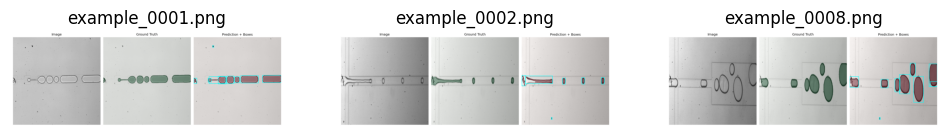

In [15]:
import os
import matplotlib.pyplot as plt
from PIL import Image

examples_dir = summary["examples_dir"]
examples = sorted(os.listdir(examples_dir))

plt.figure(figsize=(12, 6))
for i, fname in enumerate(examples[:3]):
    img = Image.open(os.path.join(examples_dir, fname))
    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(fname)
    plt.axis("off")

plt.show()

In [16]:
import pandas as pd

table = pd.DataFrame({
    "Metric": summary["semantic_metrics"].keys(),
    "Value": summary["semantic_metrics"].values()
})

print(table.to_latex(index=False))

\begin{tabular}{lr}
\toprule
Metric & Value \\
\midrule
precision & 0.891355 \\
recall & 0.901759 \\
f1 & 0.891692 \\
dice & 0.891692 \\
iou & 0.823922 \\
\bottomrule
\end{tabular}



In [17]:
experiments = [
    "results/real_test/maskrcnn_resnet50_fpn_synth_20260106_0917",
    "results/real_test/maskrcnn_resnet50_fpn_transfer_real_20260107_0921"
]

generate_experiment_comparison(experiments, out_dir="comparison_plots")

Comparing experiments:
 - results/real_test/maskrcnn_resnet50_fpn_synth_20260106_0917
 - results/real_test/maskrcnn_resnet50_fpn_transfer_real_20260107_0921


In [18]:
print(f"""
The model achieved a mean Dice score of {summary['semantic_metrics']['dice']:.4f}
and a mean IoU of {summary['semantic_metrics']['iou']:.4f}, demonstrating strong ability 
to segment bubble regions accurately.

The average number of detected bubbles per image was 
{summary['instance_metrics']['avg_bubbles']:.2f}, with a mean bubble area of 
{summary['instance_metrics']['mean_area']:.1f} pixels.

The inference speed was {summary['timing']['fps']:.1f} FPS, which is suitable for 
real-time or near-real-time applications depending on deployment requirements.
""")


The model achieved a mean Dice score of 0.8917
and a mean IoU of 0.8239, demonstrating strong ability 
to segment bubble regions accurately.

The average number of detected bubbles per image was 
21.08, with a mean bubble area of 
1785.3 pixels.

The inference speed was 5.2 FPS, which is suitable for 
real-time or near-real-time applications depending on deployment requirements.

